# Brain Tumor Segmentation Analysis

This notebook presents an exploratory analysis of a Deep U-Net model trained on the BraTS 2020 dataset for multi-class brain tumor segmentation.

The analysis focuses on:
- Tumor size distribution
- Dice Score performance
- Best and worst segmentation cases
- MRI modalities
- Tumor subregions
- Model behavior across different tumor categories

## Tumor Size Calculation

The percentage of tumor pixels is computed for randomly selected MRI samples. Tumor size is measured as the proportion of tumor pixels relative to the total image area, enabling analysis of tumor size distribution and its impact on segmentation performance.

In [19]:
import random
import h5py
import numpy as np
import os

sample_files = random.sample(files, 1000)

tumor_percents = []

for file in sample_files:

    path = os.path.join(data_path, file)

    with h5py.File(path, "r") as f:
        mask = f["mask"][:]

    tumor_pixels = np.sum(mask[:,:,1] > 0)

    if tumor_pixels == 0:
        continue

    tumor_percent = (
        tumor_pixels / (240*240)
    ) * 100

    tumor_percents.append(tumor_percent)

print("Tumor slices:", len(tumor_percents))
print("Average Tumor %:", np.mean(tumor_percents))
print("Median Tumor %:", np.median(tumor_percents))
print("Min Tumor %:", np.min(tumor_percents))
print("Max Tumor %:", np.max(tumor_percents))

Tumor slices: 447
Average Tumor %: 1.4474001056425552
Median Tumor %: 1.1770833333333333
Min Tumor %: 0.001736111111111111
Max Tumor %: 6.534722222222222


## Tumor Size Categories

Tumors are categorized into small, medium, and large groups based on their percentage area within the MRI slice. This categorization helps analyze dataset composition and enables comparison of segmentation performance across different tumor sizes.

In [21]:
small = 0
medium = 0
large = 0

for t in tumor_percents:

    if t < 1:
        small += 1
    elif t < 3:
        medium += 1
    else:
        large += 1

print("Small Tumors :", small)
print("Medium Tumors:", medium)
print("Large Tumors :", large)

Small Tumors : 197
Medium Tumors: 193
Large Tumors : 57


## Tumor Size vs Dice Score Visualization

Average Dice Scores are calculated for small, medium, and large tumors. This analysis evaluates how tumor size influences segmentation performance and helps identify whether the model performs better on larger or smaller tumor regions.

In [29]:
small = []
medium = []
large = []

for tumor_percent,dice in results:

    if tumor_percent < 1:
        small.append(dice)

    elif tumor_percent < 3:
        medium.append(dice)

    else:
        large.append(dice)

print("Small Avg Dice :", np.mean(small))
print("Medium Avg Dice:", np.mean(medium))
print("Large Avg Dice :", np.mean(large))

Small Avg Dice : 0.31829592998231393
Medium Avg Dice: 0.6753782300733413
Large Avg Dice : 0.7942430787488712


## Tumor Size vs Dice Score

This visualization compares the average Dice Scores obtained for small, medium, and large tumors. The analysis highlights the relationship between tumor size and segmentation accuracy, demonstrating how model performance varies across different tumor categories.

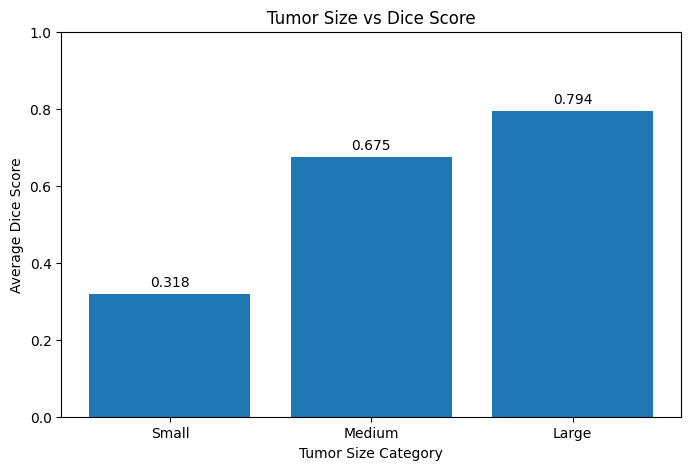

In [30]:
import matplotlib.pyplot as plt

categories = ["Small", "Medium", "Large"]
dice_scores = [0.318, 0.675, 0.794]

plt.figure(figsize=(8,5))
plt.bar(categories, dice_scores)

plt.title("Tumor Size vs Dice Score")
plt.xlabel("Tumor Size Category")
plt.ylabel("Average Dice Score")

for i, v in enumerate(dice_scores):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center")

plt.ylim(0,1)
plt.show()

## Best Case Segmentation

This example represents one of the highest-performing predictions produced by the Deep U-Net model. The predicted mask closely matches the expert-annotated ground-truth segmentation, achieving a Dice Score of approximately 0.96 and demonstrating excellent tumor localization accuracy.

I0000 00:00:1782062751.800037     161 service.cc:152] XLA service 0x7e5558002ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782062751.800077     161 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782062751.800080     161 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782062752.169293     161 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782062755.320633     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


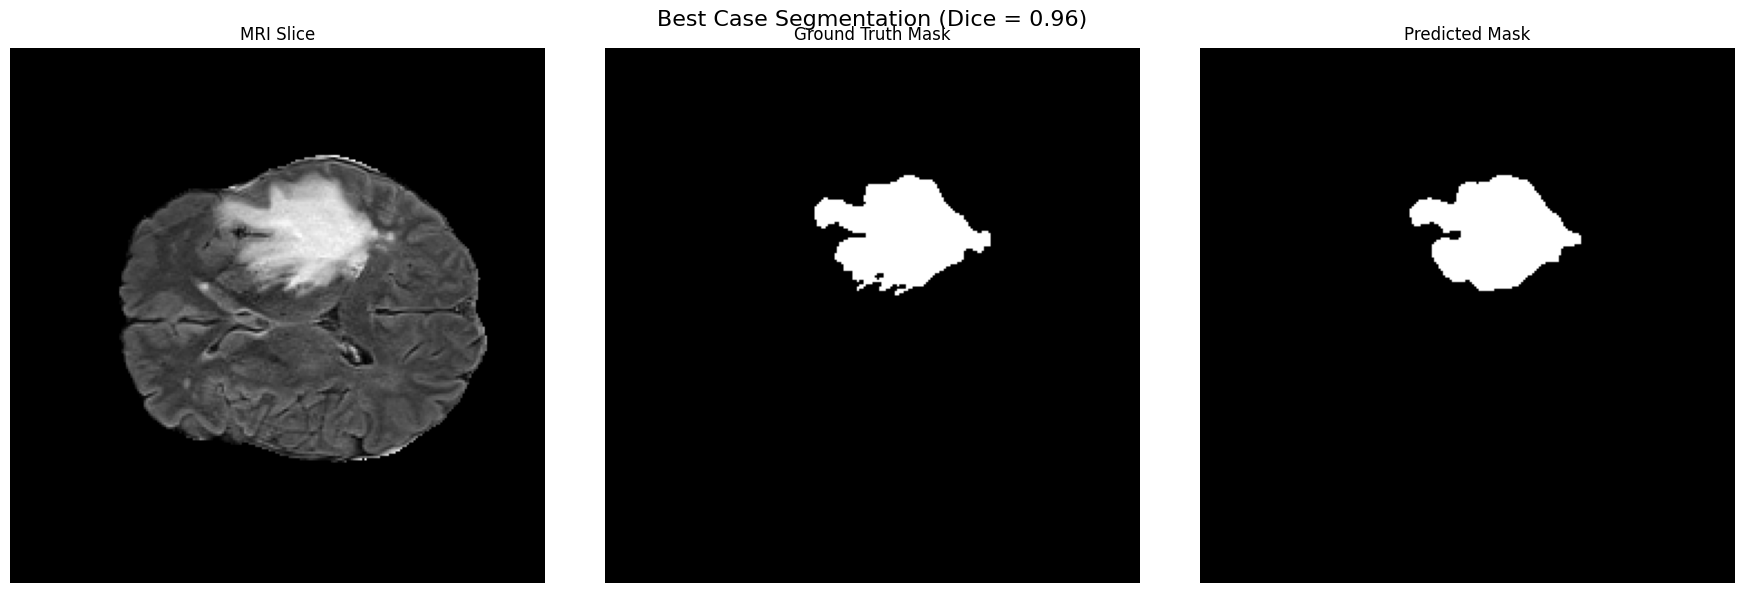

In [ ]:

np.expand_dims(image,import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

best_file = "volume_93_slice_76.h5"

path = os.path.join(data_path, best_file)

with h5py.File(path, "r") as f:
    image = f["image"][:]
    mask = f["mask"][:]

pred = deep_model.predict( axis=0),
    verbose=0
)

pred_bin = (pred > 0.5).astype(np.float32)

gt = mask[:, :, 1]
pr = pred_bin[0, :, :, 1]

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image[:,:,0], cmap="gray")
plt.title("MRI Slice")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pr, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.suptitle("Best Case Segmentation (Dice = 0.96)", fontsize=16)
plt.tight_layout()

plt.show()

### Key Observation

The predicted tumor boundary closely follows the ground-truth annotation, resulting in a very high Dice Score. This indicates that the model can accurately capture tumor shape and location when sufficient tumor information is present in the MRI slice.

## Predicted Tumor Overlay

The predicted segmentation mask is overlaid on the original MRI image to visualize tumor localization. This representation makes it easier to assess how accurately the Deep U-Net model identifies tumor regions within the brain MRI scan.

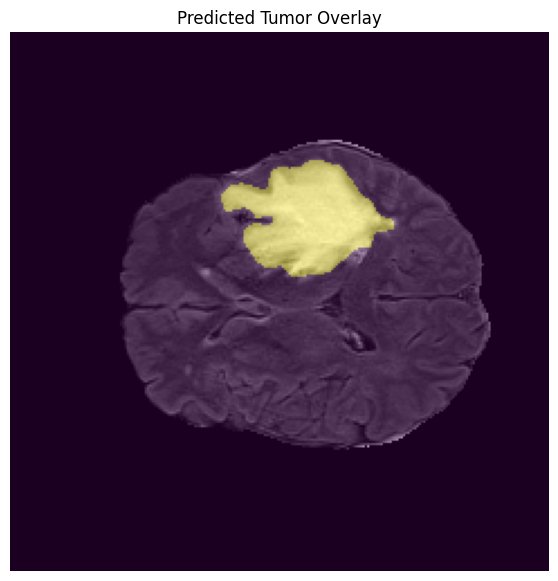

In [12]:
plt.figure(figsize=(7,7))

plt.imshow(image[:,:,0], cmap="gray")
plt.imshow(pr, alpha=0.4)

plt.title("Predicted Tumor Overlay")
plt.axis("off")

plt.show()

### Key Observation

The overlay confirms that the predicted tumor region is concentrated within the expected anatomical location and closely follows the tumor boundaries observed in the MRI scan.

## Worst Case Segmentation

This example represents a challenging MRI slice where the Deep U-Net model achieved a relatively low Dice Score. Comparing the predicted and ground-truth masks helps identify segmentation errors and provides insight into the model's limitations.

I0000 00:00:1782109698.639400     138 service.cc:152] XLA service 0x7a3d700073d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782109698.639438     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782109698.639441     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782109698.967150     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782109701.896293     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


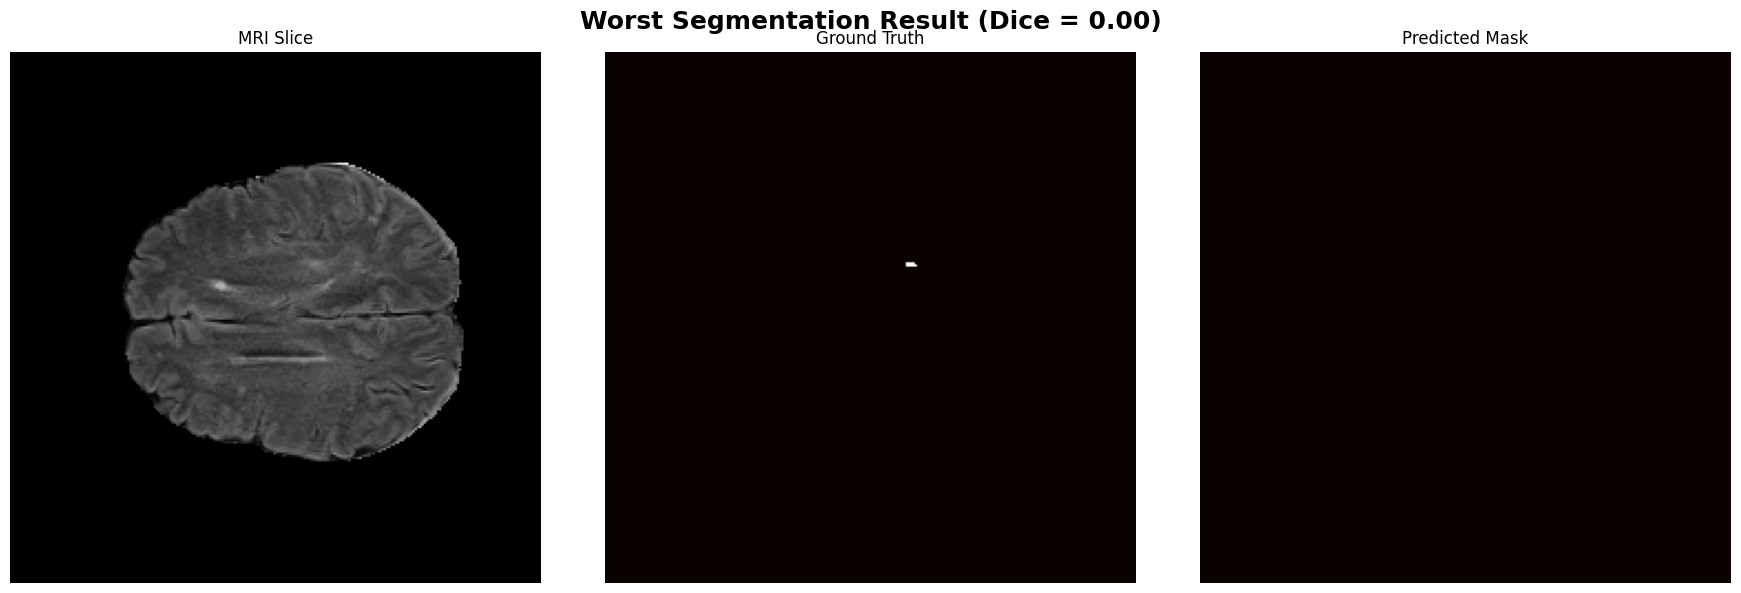

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

worst_file = "volume_93_slice_94.h5"

path = os.path.join(data_path, worst_file)

with h5py.File(path, "r") as f:
    image = f["image"][:]
    mask = f["mask"][:]

pred = deep_model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

pred_bin = (pred > 0.5).astype(np.float32)

gt = mask[:,:,1]
pr = pred_bin[0,:,:,1]

fig, ax = plt.subplots(1,3,figsize=(18,6))

ax[0].imshow(image[:,:,0], cmap="gray")
ax[0].set_title("MRI Slice")
ax[0].axis("off")

ax[1].imshow(gt, cmap="hot")
ax[1].set_title("Ground Truth")
ax[1].axis("off")

ax[2].imshow(pr, cmap="hot")
ax[2].set_title("Predicted Mask")
ax[2].axis("off")

plt.suptitle(
    "Worst Segmentation Result (Dice = 0.00)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/worst_case_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Observation

The predicted mask does not fully capture the tumor boundaries observed in the ground-truth annotation. This suggests that small or complex tumor regions remain challenging for the model and contribute to reduced segmentation performance.

## Tumor Mask Channels

The segmentation mask is analyzed channel-wise to identify the presence and distribution of tumor regions. Examining individual channels helps verify mask annotations and understand how different tumor subregions are represented in the dataset.

In [6]:
import h5py
import os
import numpy as np

file_name = "volume_93_slice_76.h5"

with h5py.File(os.path.join(data_path, file_name), "r") as f:
    mask = f["mask"][:]

print(mask.shape)

for i in range(mask.shape[-1]):
    print(f"Channel {i} pixels =", np.sum(mask[:,:,i]))

(240, 240, 3)
Channel 0 pixels = 0
Channel 1 pixels = 2412
Channel 2 pixels = 0


## Multi-Class Tumor Region Detection

MRI slices containing multiple tumor subregions are identified by examining all segmentation mask channels. These samples provide useful examples for visualizing and understanding multi-class tumor segmentation.

In [7]:
import h5py
import os
import numpy as np

for file in files[:2000]:

    with h5py.File(os.path.join(data_path, file), "r") as f:
        mask = f["mask"][:]

    ch0 = np.sum(mask[:,:,0])
    ch1 = np.sum(mask[:,:,1])
    ch2 = np.sum(mask[:,:,2])

    nonzero = sum([ch0>0, ch1>0, ch2>0])

    if nonzero >= 2:
        print(file)
        print("Channel0:", ch0)
        print("Channel1:", ch1)
        print("Channel2:", ch2)
        break

volume_293_slice_67.h5
Channel0: 1411
Channel1: 2721
Channel2: 447


## Tumor Subregion Visualization

Individual tumor mask channels are combined into a single multi-class segmentation map. Different colors represent different tumor subregions, providing a comprehensive visualization of the tumor structure within the MRI slice.

### Color Representation

- Class 1 → Tumor Subregion 1
- Class 2 → Tumor Subregion 2
- Class 3 → Tumor Subregion 3

The combined mask helps visualize the relationship between different tumor regions within a single MRI slice.

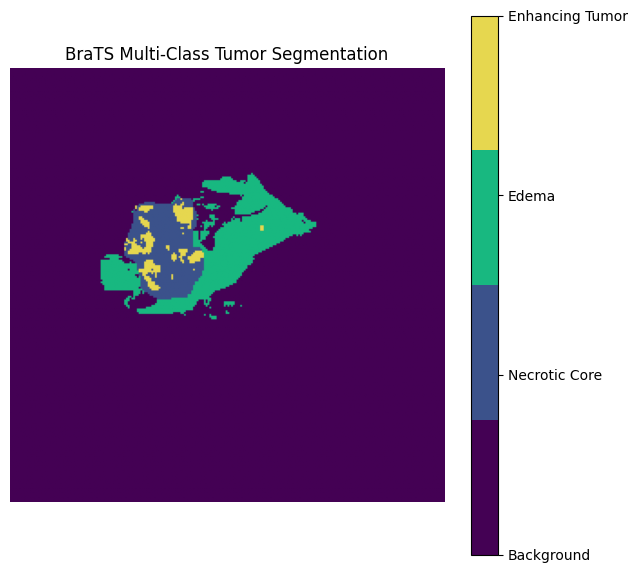

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap

file_name = "volume_293_slice_67.h5"

with h5py.File(os.path.join(data_path, file_name), "r") as f:
    image = f["image"][:]
    mask = f["mask"][:]

multi_mask = np.zeros((240,240))

multi_mask[mask[:,:,0] > 0] = 1
multi_mask[mask[:,:,1] > 0] = 2
multi_mask[mask[:,:,2] > 0] = 3

cmap = ListedColormap([
    "#440154",  # background
    "#3b528b",  # class 1
    "#18b880",  # class 2
    "#e6d74f"   # class 3
])

plt.figure(figsize=(7,7))

plt.imshow(
    multi_mask,
    cmap=cmap,
    vmin=0,
    vmax=3
)

cbar = plt.colorbar()
cbar.set_ticks([0,1,2,3])

cbar.set_ticklabels([
    "Background",
    "Necrotic Core",
    "Edema",
    "Enhancing Tumor"
])


plt.title("BraTS Multi-Class Tumor Segmentation")
plt.axis("off")

plt.savefig(
    "/kaggle/working/brats_multiclass_labels.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## MRI Modalities

The BraTS dataset contains four MRI modalities: FLAIR, T1CE, T2, and T1. Each modality provides complementary information about brain anatomy and tumor characteristics, helping the Deep U-Net model achieve more accurate segmentation.

### Key Observation

Different MRI modalities emphasize different tissue properties. Tumor regions may appear more prominent in certain modalities, demonstrating the importance of multi-modal MRI data for accurate brain tumor segmentation.

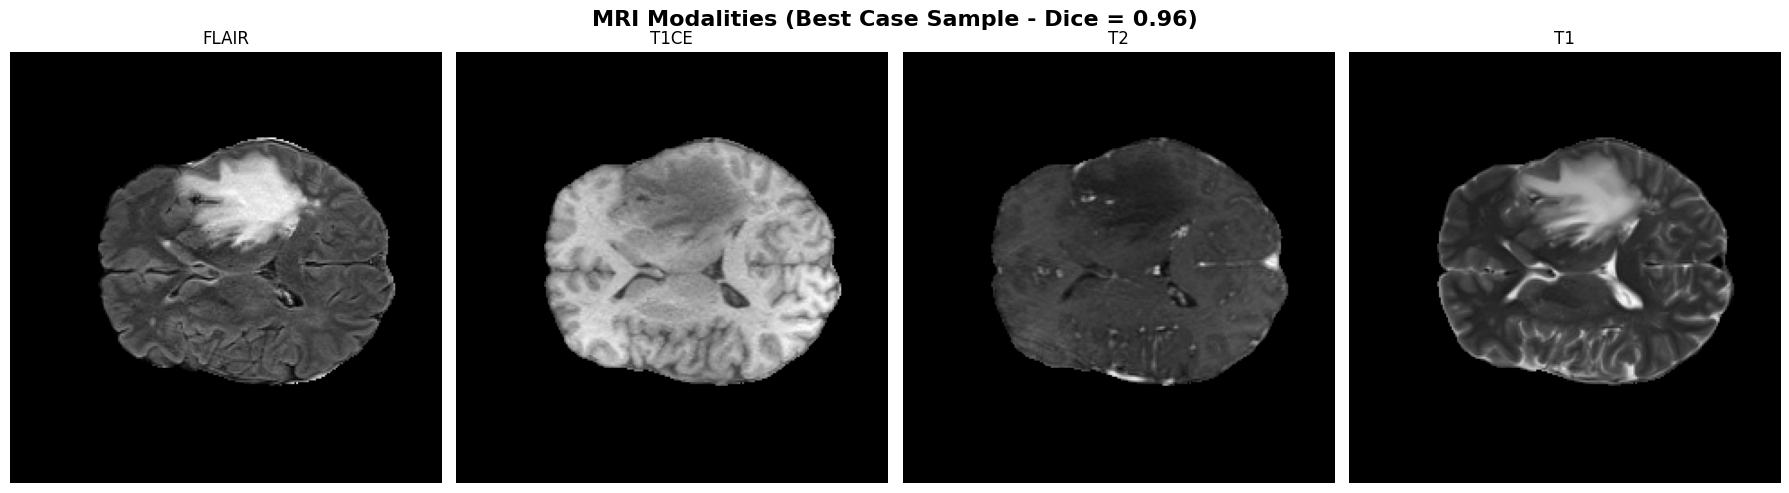

In [20]:
import h5py
import matplotlib.pyplot as plt
import os

best_file = "volume_93_slice_76.h5"

with h5py.File(os.path.join(data_path, best_file), "r") as f:
    image = f["image"][:]

fig, ax = plt.subplots(1,4, figsize=(18,5))

titles = ["FLAIR", "T1CE", "T2", "T1"]

for i in range(4):
    ax[i].imshow(image[:,:,i], cmap="gray")
    ax[i].set_title(titles[i], fontsize=12)
    ax[i].axis("off")

plt.suptitle(
    "MRI Modalities (Best Case Sample - Dice = 0.96)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/mri_modalities_best_case.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Tumor Subregions

The BraTS dataset provides separate mask channels for different tumor subregions. This visualization displays the individual tumor components along with a combined multi-class mask, providing a comprehensive view of tumor structure within the MRI slice.

### Key Observation

Different tumor subregions occupy distinct anatomical locations and exhibit varying shapes and sizes. Combining these regions into a single visualization highlights the complexity of brain tumor segmentation and demonstrates why multi-class segmentation is more challenging than simple tumor detection.

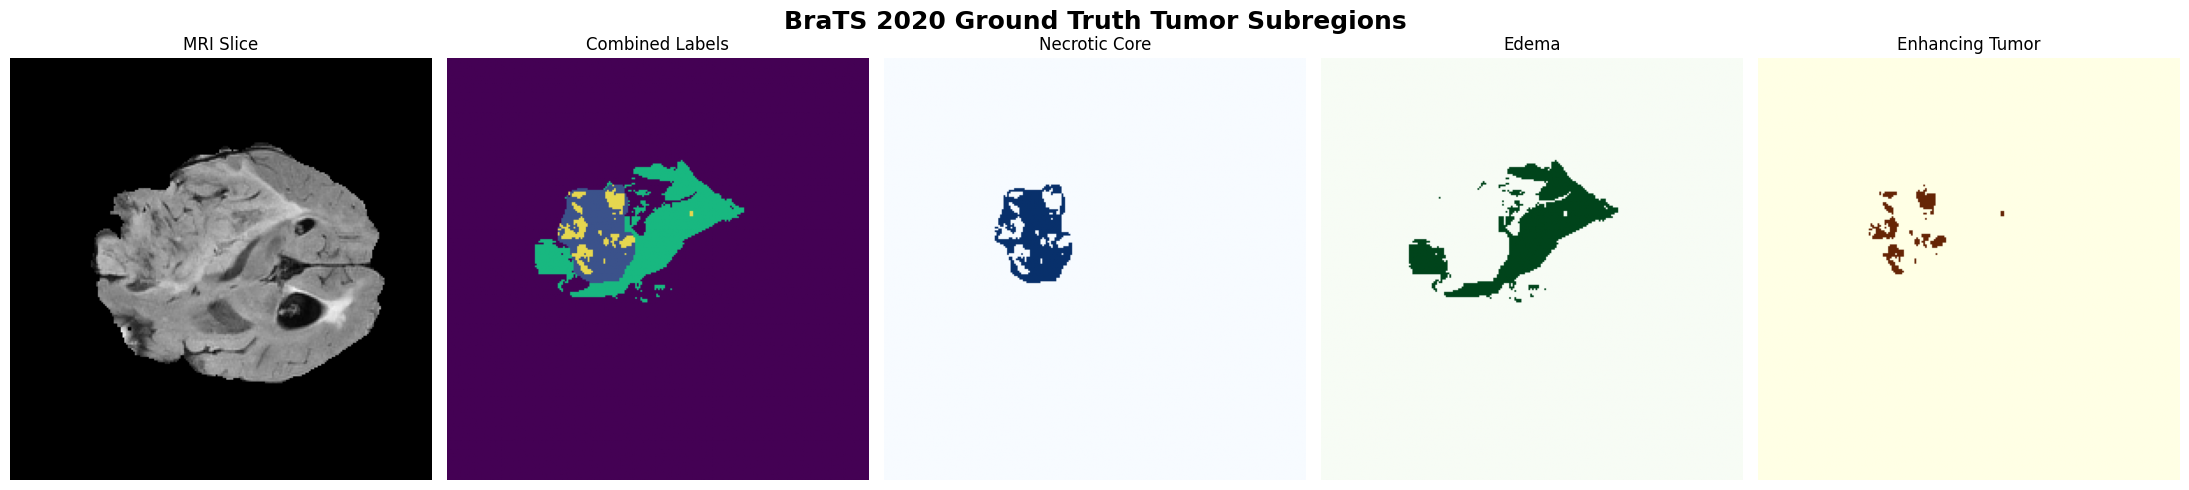

In [21]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import ListedColormap

file_name = "volume_293_slice_67.h5"

with h5py.File(os.path.join(data_path, file_name), "r") as f:
    image = f["image"][:]
    mask = f["mask"][:]

# MRI (FLAIR)
mri = image[:, :, 0]

# Individual classes
class1 = mask[:, :, 0]   # Necrotic Core
class2 = mask[:, :, 1]   # Edema
class3 = mask[:, :, 2]   # Enhancing Tumor

# Combined mask
combined = np.zeros((240,240))
combined[class1 > 0] = 1
combined[class2 > 0] = 2
combined[class3 > 0] = 3

cmap = ListedColormap([
    "#440154",  # background
    "#3b528b",  # class 1
    "#18b880",  # class 2
    "#e6d74f"   # class 3
])

fig, ax = plt.subplots(1,5, figsize=(22,5))

# MRI
ax[0].imshow(mri, cmap="gray")
ax[0].set_title("MRI Slice")
ax[0].axis("off")

# Combined
ax[1].imshow(combined, cmap=cmap, vmin=0, vmax=3)
ax[1].set_title("Combined Labels")
ax[1].axis("off")

# Class 1
ax[2].imshow(class1, cmap="Blues")
ax[2].set_title("Necrotic Core")
ax[2].axis("off")

# Class 2
ax[3].imshow(class2, cmap="Greens")
ax[3].set_title("Edema")
ax[3].axis("off")

# Class 3
ax[4].imshow(class3, cmap="YlOrBr")
ax[4].set_title("Enhancing Tumor")
ax[4].axis("off")

plt.suptitle(
    "BraTS 2020 Ground Truth Tumor Subregions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/brats_tumor_subregions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Tumor Size Distribution

This chart illustrates the number of MRI slices belonging to small, medium, and large tumor categories. Analyzing the distribution of tumor sizes helps understand dataset characteristics and provides context for subsequent segmentation performance analysis.

### Key Observation

The dataset contains a comparable number of small and medium tumor slices, while large tumors are relatively less frequent. This imbalance may influence model performance and partially explain variations in Dice Scores across different tumor size categories.

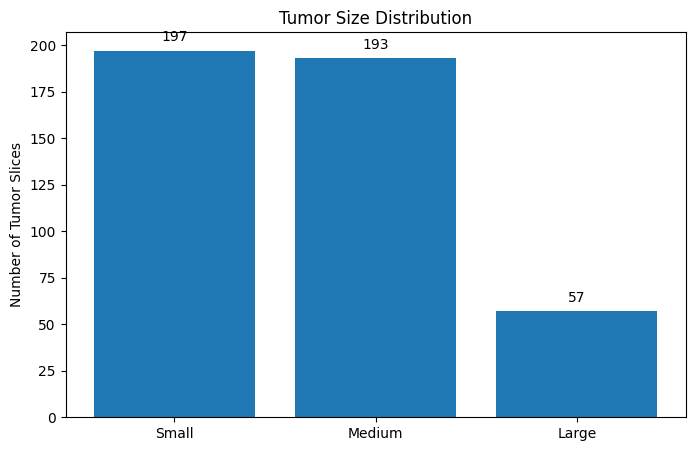

In [29]:
import matplotlib.pyplot as plt

categories = ["Small", "Medium", "Large"]
counts = [197, 193, 57]

plt.figure(figsize=(8,5))
plt.bar(categories, counts)

for i, v in enumerate(counts):
    plt.text(i, v+5, str(v), ha="center")

plt.title("Tumor Size Distribution")
plt.ylabel("Number of Tumor Slices")

plt.savefig(
    "/kaggle/working/tumor_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The Deep U-Net model demonstrated strong performance for large tumors while smaller tumors remained challenging to segment accurately.

Key findings:
- Dice Score improved with increasing tumor size.
- Multi-modal MRI inputs provided complementary anatomical information.
- Best-case predictions achieved near-perfect overlap with ground-truth masks.
- Multi-class visualization highlighted the complexity of brain tumor segmentation.

Future work may include Attention U-Net, Residual U-Net, and transformer-based segmentation architectures.